In [1]:
import pandas as pd
import numpy as np

In [2]:
def safe_convert(col):
    col_cleaned = col.replace(',', '', regex=True)
    return pd.to_numeric(col_cleaned, errors='coerce')

setpt = pd.read_csv('setpoint_publish(in).csv')
setpt = setpt.apply(lambda col: safe_convert(col) if col.name != 'var' else col)
setpt.columns = setpt.columns.str.strip() #delete whitespace in csv file
setpt

,var,opt_mean,opt_sig,drift_mean,drift_sig,excursion_mean,excursion_sig
0,x1,22.1,0.295,22.111,0.442,22.115,0.5900
1,x2,44.8,1.045,46.010,1.840,46.547,2.3270
2,x4,0.4,0.023,0.368,0.027,0.304,0.0670
3,x5,150000.0,8000.000,135000.000,9000.000,120000.000,16000.0000
4,x7,1206.0,48.240,1266.300,75.978,1266.300,88.6410
5,x8,87.0,5.220,91.176,6.686,107.880,12.2264
6,x9,454.0,19.673,456.270,22.814,599.280,69.9160
7,x17,5492.0,256.293,5526.050,349.983,5552.410,425.6850
8,x3,NaN,NaN,39.000,2.860,NaN,NaN
9,x6,NaN,NaN,112.000,6.720,NaN,NaN


In [3]:
number_of_wafers = 5000

def generate_normal_data(mean, std_dev, size=number_of_wafers, seed=None):
    return np.random.normal(loc=mean, scale=std_dev, size=size)

In [4]:
from scipy.stats import skewnorm

def generate_skewed_data(mean, sig, alpha, size=number_of_wafers):
    return skewnorm.rvs(a=alpha, loc=mean, scale=sig, size=number_of_wafers)

In [5]:
datasets = {}
for data_name in ["opt", "drift", "excursion"]:
    rows = []
    for var, mean, sig in zip(setpt['var'], setpt[f'{data_name}_mean'], setpt[f'{data_name}_sig']):
        if data_name=="excursion" and var in ["x4","x5"]:
            rows.append(generate_skewed_data(mean, sig, alpha=200))
        elif data_name=="excursion" and var=="x8":
            rows.append(generate_skewed_data(mean, sig, alpha=-100))
        elif data_name=="excursion" and var=="x9":
            rows.append(generate_skewed_data(mean, sig, alpha=-200))
        else:
            rows.append(generate_normal_data(mean, sig, seed=42))
    
    datasets[data_name] = pd.DataFrame(np.column_stack(rows), columns=setpt['var'])

In [6]:
opt_data = datasets['opt']
drift_data = datasets['drift']
exc_data = datasets['excursion']

# Outcome 

In [7]:
#function from first task sheet
#opt_data['outcome'] = -( 4 * np.pi * opt_data['x1'] + (77 / 100) * (opt_data['x2'] ** 2) +
#   58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 33.5 * opt_data['x7'] ) / (8 * 10**5)

opt_data['outcome'] = (-( 5 * np.pi * 10**4 * opt_data['x1'] + 770 * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 730.5 * opt_data['x7'] ) / (8 * 10**5) + 7.5)

#function from first task sheet
#drift_data['outcome'] = (-( 4 * np.pi * drift_data['x1'] + (77 / 100) * (drift_data['x2'] ** 2) +
#    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 33.5 * drift_data['x7'] ) / (8 * 10**5)) 
#+ (19 * drift_data['x5'] * drift_data['x9'] * drift_data['x8'] / (10**11))

drift_data['outcome'] = (-( 5 * np.pi * 10**4 * drift_data['x1'] + 770 * (drift_data['x2'] ** 2) +
    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 730.5 * drift_data['x7'] ) / (8 * 10**5) 
    + (39 * drift_data['x5'] * drift_data['x9'] * drift_data['x8']) / (10**11) + 7) 

#function from first task sheet
#exc_data['outcome'] = (-( 4 * np.pi * exc_data['x1'] + (77 / 100) * (exc_data['x2'] ** 2) +
#    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 33.5 * exc_data['x7'] ) / (8 * 10**5)) 
#+ ((19 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11)) 
#+ ((0.8 * exc_data['x4'] * (exc_data['x5']**2) * exc_data['x17'] ) / (10**13))

exc_data['outcome'] = (-( 5 * np.pi * 10**4 * exc_data['x1'] + 770 * (exc_data['x2'] ** 2) +
    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 730.5 * exc_data['x7'] ) / (8 * 10**5) 
    + (39 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11) + 7 
    + ((0.8 * exc_data['x4'] * (exc_data['x5'])**2 * exc_data['x17'] ) / (10**13)))


In [8]:
opt_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,21.891481,46.335227,0.406320,160208.795354,1175.930728,83.091641,462.175917,5587.019728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.557505
1,21.871370,44.612387,0.376835,150605.601558,1200.084881,86.269618,429.769226,5094.056449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.746622
2,22.100943,42.934168,0.379018,153259.115945,1171.644192,78.260426,457.093944,5526.922827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.253740
3,22.175226,42.988481,0.388614,134589.986740,1118.173443,85.006639,474.014336,6085.800167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.324609
4,21.765595,42.835925,0.394641,145182.788098,1080.337056,81.703000,473.305499,5081.889413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.973454


In [9]:
drift_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,22.291593,43.195693,0.342376,129544.434479,1323.800668,82.873887,489.819980,5291.455543,39.514044,106.683551,582.932839,8.213993,12912.876561,351.036978,8493.364944,25.974556,644.329795,118704.862091,6314.052628,4.340387
1,20.589389,45.534472,0.406231,138985.101040,1198.824644,94.735214,445.550353,5244.209849,40.982431,104.817176,546.087364,7.793181,13100.923294,301.101427,7763.860699,28.663734,684.388897,136648.182572,6642.783256,3.895716
2,21.943923,47.807768,0.412177,119215.194462,1299.828797,101.928108,466.002717,5973.778120,39.708761,102.502890,541.238001,7.838659,14134.957879,308.668332,8742.561618,27.143341,656.586883,120240.495148,6488.435032,4.596287
3,21.315799,44.784733,0.332624,119626.530062,1285.966195,96.097109,452.640238,5423.083976,38.473199,111.126221,531.134613,7.864186,13733.037631,315.862961,8284.950144,27.721330,671.143339,120014.750449,6363.964786,4.887651
4,22.687191,45.943263,0.383960,150872.409167,1199.887278,95.122066,455.185729,5606.891288,39.566142,114.183504,549.057915,8.257740,13517.606236,286.778216,8970.169236,29.899406,646.945555,134236.084848,6915.052622,4.003593


In [10]:
exc_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,21.751557,44.770185,0.306942,127750.288029,1388.748454,100.760921,541.301817,5482.184696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.702247
1,23.141766,49.395836,0.331317,141673.977721,1433.078548,98.536437,492.580684,5059.850127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.398771
2,21.472418,42.917100,0.414978,158877.732012,1411.660677,104.158023,573.961954,5327.881560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.038371
3,22.647339,46.790582,0.313455,122880.470589,1229.308182,101.212097,471.170394,6142.737164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.975999
4,21.682688,44.410889,0.364004,152648.716567,1313.227238,96.398650,449.130977,5981.819897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.907927


In [11]:
opt_data.to_csv("data/opt_data.csv", index=None)
drift_data.to_csv("data/drift_data.csv", index=None)
exc_data.to_csv("data/excursion_data.csv", index=None)

# Visualize Kernel Density Plot

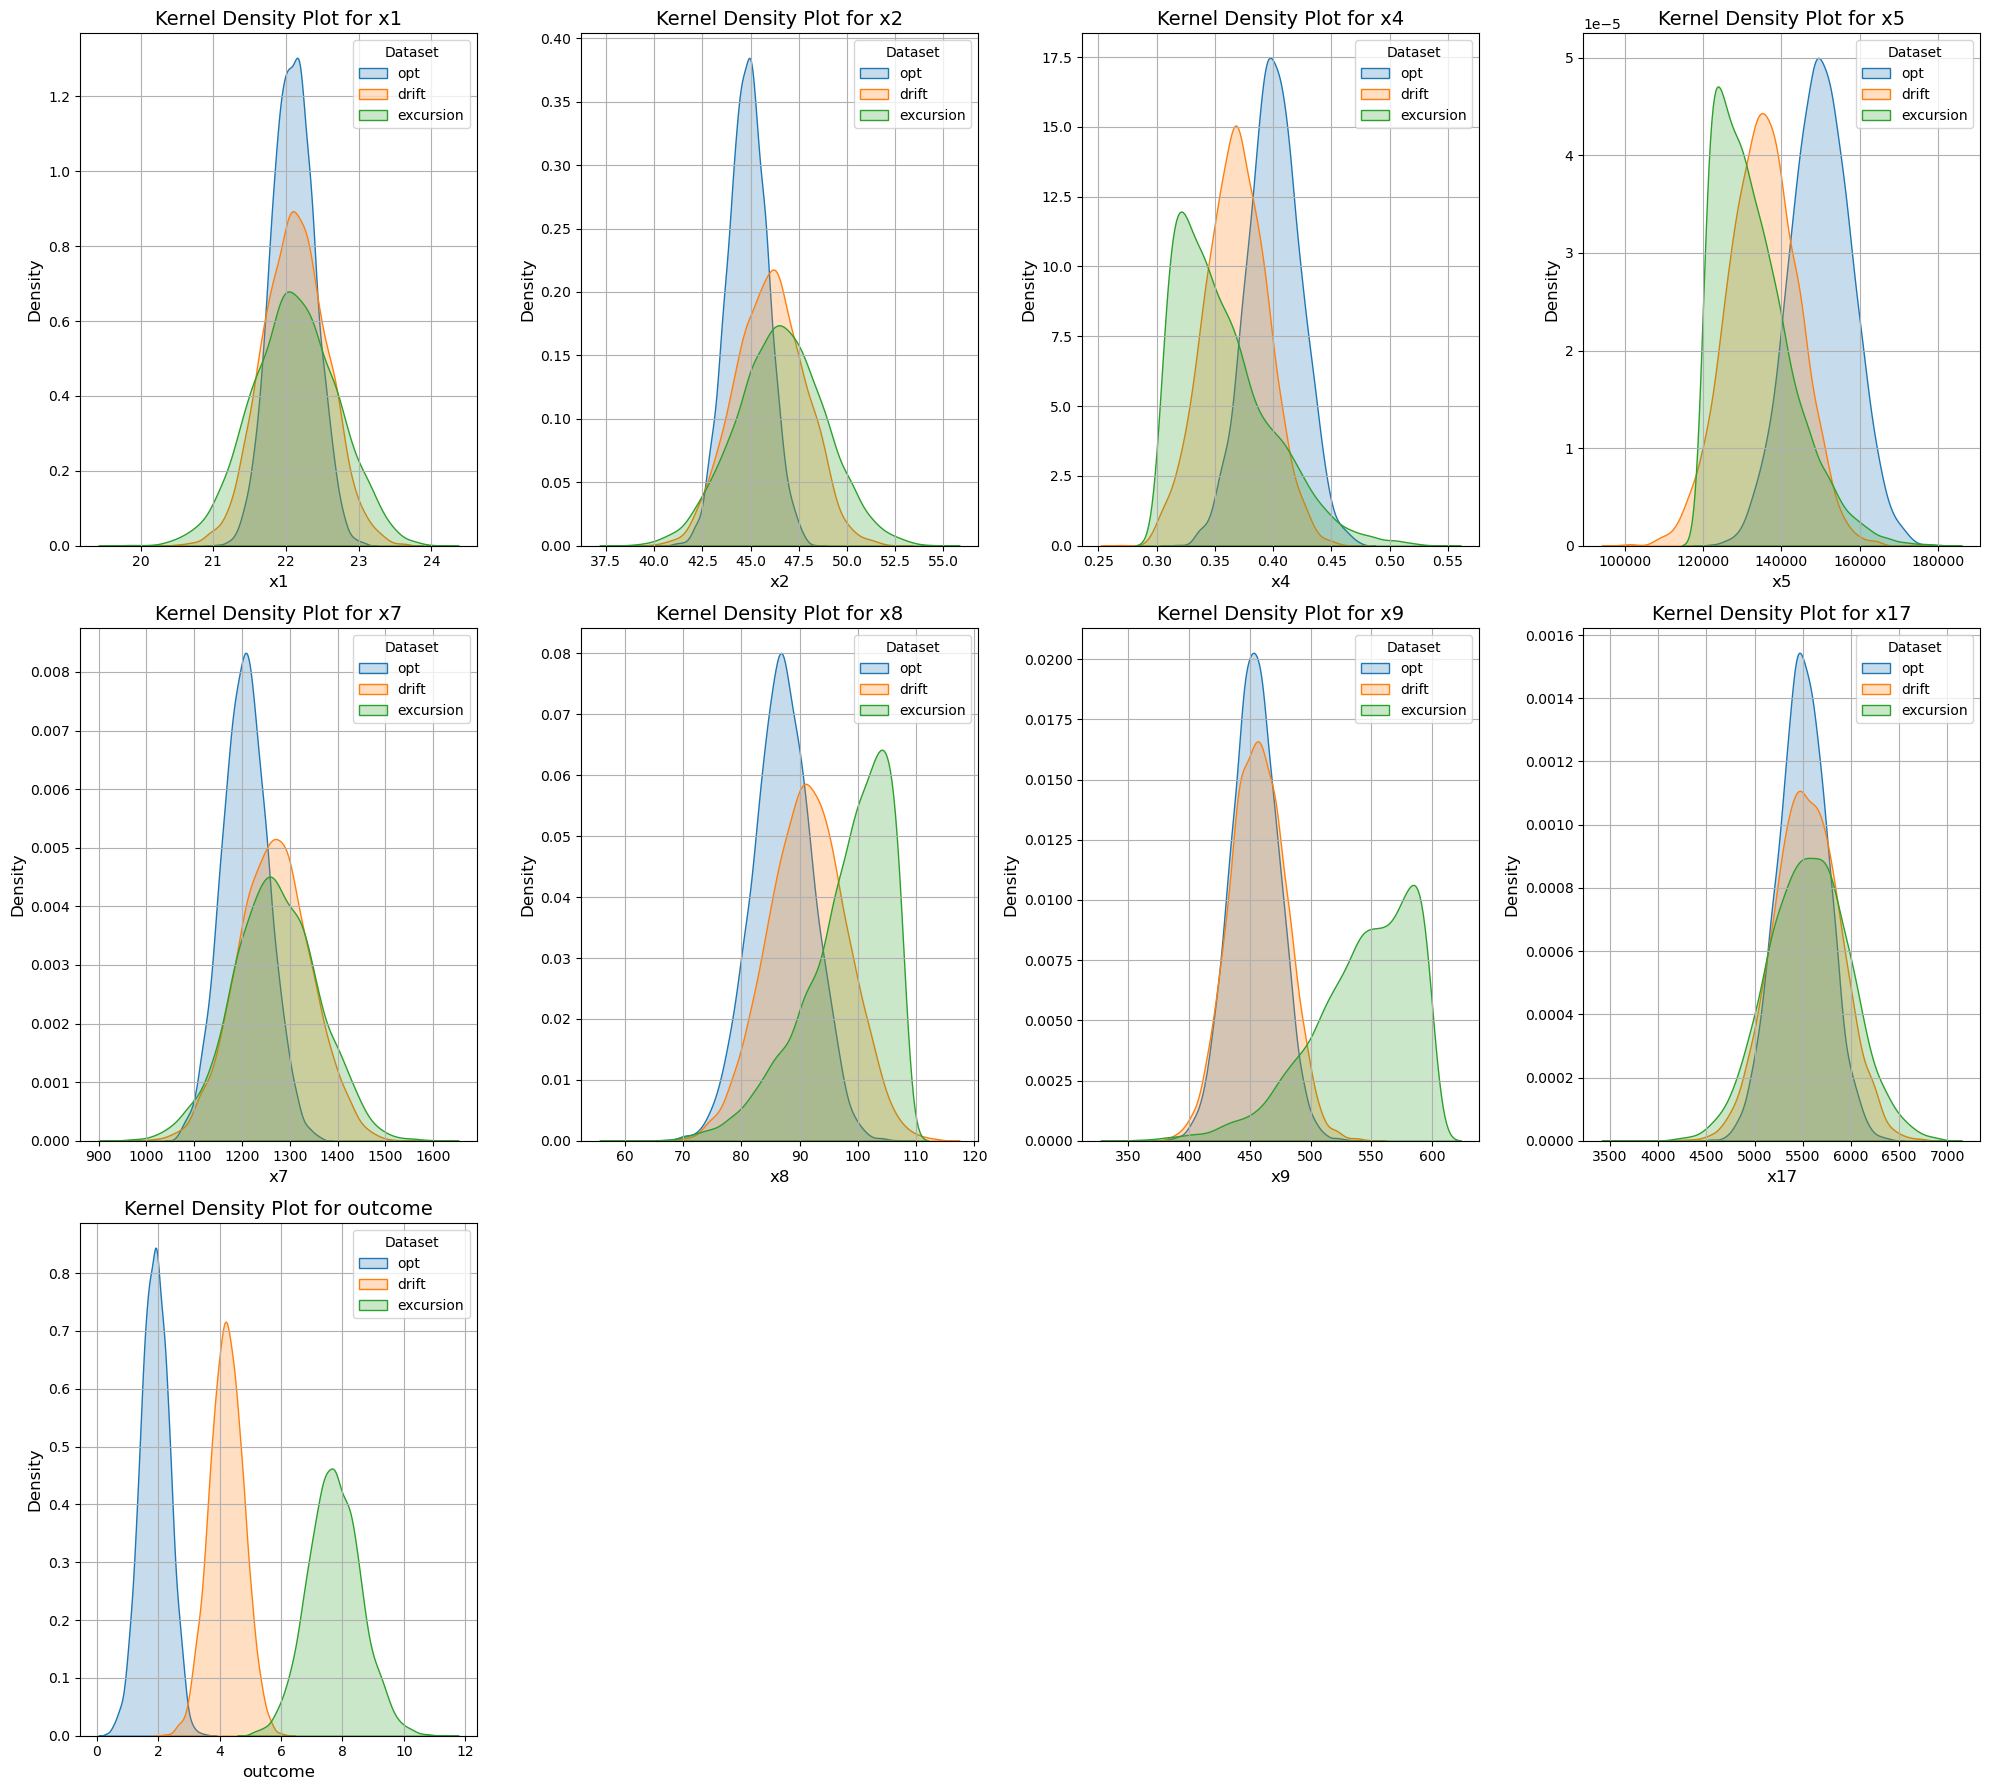

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {
    'opt': opt_data,
    'drift': drift_data,
    'excursion': exc_data
}

variables = opt_data.columns.drop([' x3 ', ' x6 ',' x10 ', ' x11 ', ' x12 ', ' x13 ', ' x14 ', ' x15 ', ' x16 ', ' x18 ',' x19 '])

plots_per_row = 4

num_variables = len(variables)
num_rows = (num_variables + plots_per_row - 1) // plots_per_row 

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, 6 * num_rows))
axes = axes.flatten()  

for i, variable in enumerate(variables):
    ax = axes[i]
    for name, df in datasets.items():
        sns.kdeplot(df[variable], label=name, fill=True, ax=ax)
    ax.set_title(f'Kernel Density Plot for {variable}', fontsize=14)
    ax.set_xlabel(variable, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(title='Dataset')
    ax.grid(True)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Sanity Check
Correlation

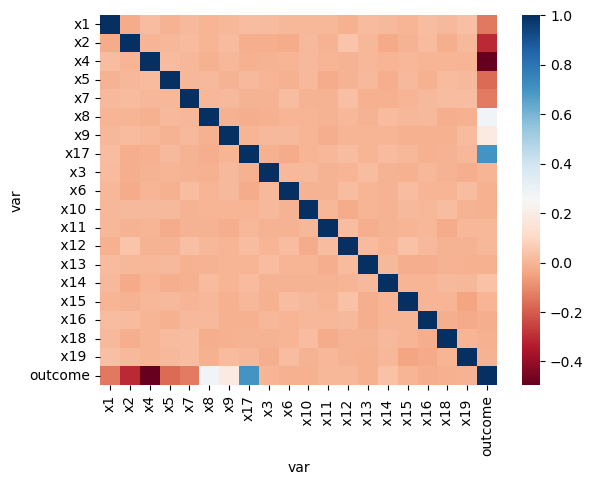

In [13]:
corr = drift_data.corr()

sns.heatmap(corr, 
            cmap='RdBu', 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)
plt.show()

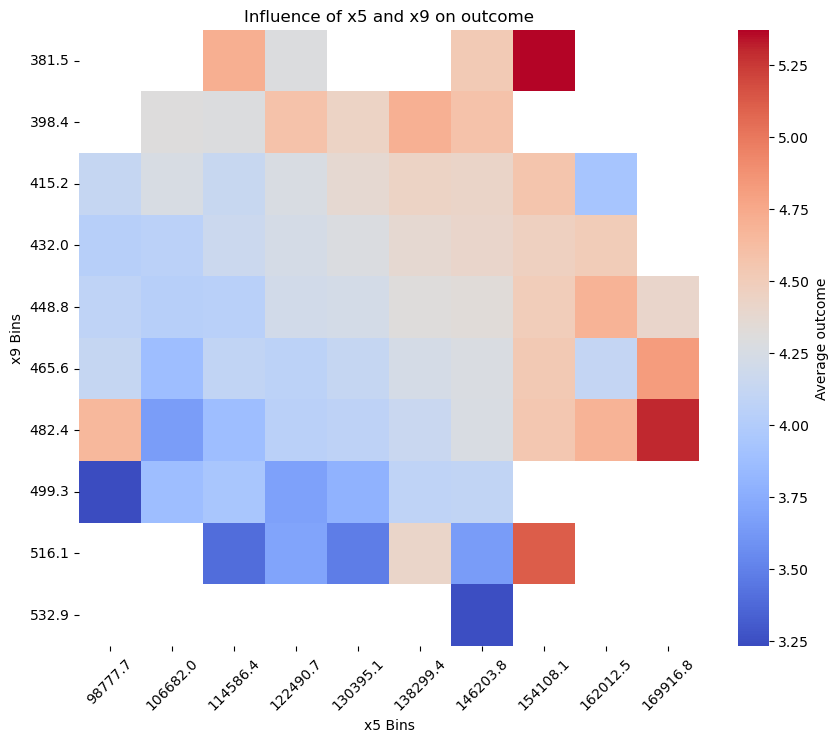

In [14]:
# Create a DataFrame
data = drift_data.copy()

# Define the number of bins for x and y
n_bins = 10
x_bins = np.linspace(data["x5"].min(), data["x5"].max(), n_bins + 1)
y_bins = np.linspace(data["x9"].min(), data["x9"].max(), n_bins + 1)

# Categorize x and y into bins
data['x5_bin'] = pd.cut(data['x5'], bins=x_bins, labels=False, include_lowest=True)
data['x9_bin'] = pd.cut(data['x9'], bins=y_bins, labels=False, include_lowest=True)

# Compute the average outcome value for each bin pair
heatmap_data = data.groupby(['x5_bin', 'x9_bin'])['outcome'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Average outcome'})
plt.title("Influence of x5 and x9 on outcome")
plt.xlabel("x5 Bins")
plt.ylabel("x9 Bins")
plt.xticks(ticks=np.arange(len(x_bins) - 1) + 0.5, labels=[f"{x_bins[i]:.1f}" for i in range(len(x_bins) - 1)], rotation=45)
plt.yticks(ticks=np.arange(len(y_bins) - 1) + 0.5, labels=[f"{y_bins[i]:.1f}" for i in range(len(y_bins) - 1)], rotation=0)
plt.show()


# ML Model 1: Random Forest

decision trees are built right up front,
explanation: https://www.youtube.com/watch?v=v6VJ2RO66Ag

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pprint import pprint
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error


X = drift_data.drop(['outcome'],axis=1)
y = drift_data['outcome']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"R2 Score: {score}")


R2 Score: 0.9080328840634939


Fold 1 R2 Score: 0.9095953282833271
Fold 2 R2 Score: 0.9093034088791637
Fold 3 R2 Score: 0.8963737892963014
Fold 4 R2 Score: 0.9056007004096998
Fold 5 R2 Score: 0.9216233194094892
Fold 6 R2 Score: 0.910016747100366
Fold 7 R2 Score: 0.9017589323982372
Fold 8 R2 Score: 0.9049099067112171
Fold 9 R2 Score: 0.9105864999940279
Fold 10 R2 Score: 0.9184884200863659
Average R2 Score: 0.9088257052568196


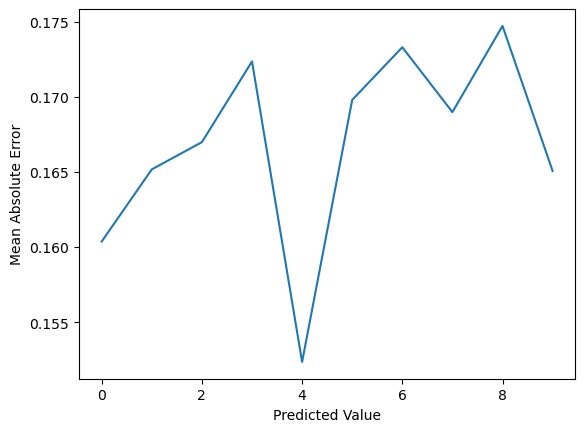

In [ ]:
#Cross-Validation

k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)
scores = []
errors = []
predicted = []

# Iterate over the splits
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    predicted.append(y_pred)

    score = r2_score(y_test, y_pred)
    scores.append(score)

    # calculate error
    rms = root_mean_squared_error(y_test, y_pred)
    errors.append(rms)
    
    print(f"Fold {fold+1} R2 Score: {score}")

# Calculate the average score
average_score = sum(scores) / len(scores)
print(f"Average R2 Score: {average_score}")

plt.plot(errors)
plt.xlabel('Predicted Value')
plt.ylabel('Mean Absolute Error')
plt.show()


   Feature  Importance
7      x17    0.491104
2       x4    0.236452
1       x2    0.078352
5       x8    0.071188
6       x9    0.028724
3       x5    0.021198
0       x1    0.016222
4       x7    0.010761
11    x11     0.004445
18    x19     0.004403
8      x3     0.004376
10    x10     0.004335
12    x12     0.004293
17    x18     0.004289
16    x16     0.004131
9      x6     0.004058
14    x14     0.004030
13    x13     0.003829
15    x15     0.003810


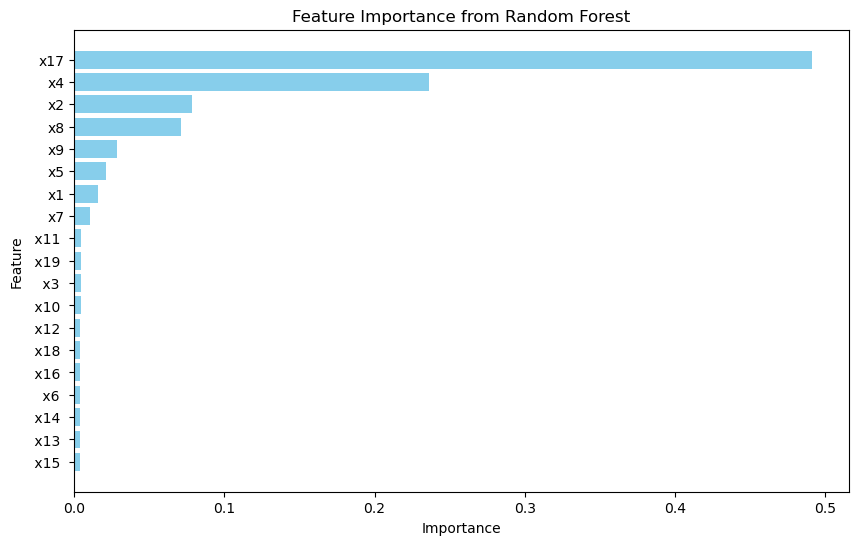

In [ ]:
# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display feature importances
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()

## ML Model 2: XGB Regressor

decision trees are built one after another, each tree is built on reducing the loss of the previous one, explanation: https://www.youtube.com/watch?v=uV2gdNt2MLc

   Feature  Importance
7      x17    0.513407
2       x4    0.194378
5       x8    0.094228
1       x2    0.074382
6       x9    0.040735
3       x5    0.031944
4       x7    0.020505
0       x1    0.015071
12    x12     0.001837
16    x16     0.001825
15    x15     0.001730
13    x13     0.001515
17    x18     0.001372
11    x11     0.001280
14    x14     0.001275
9      x6     0.001256
10    x10     0.001225
18    x19     0.001027
8      x3     0.001007


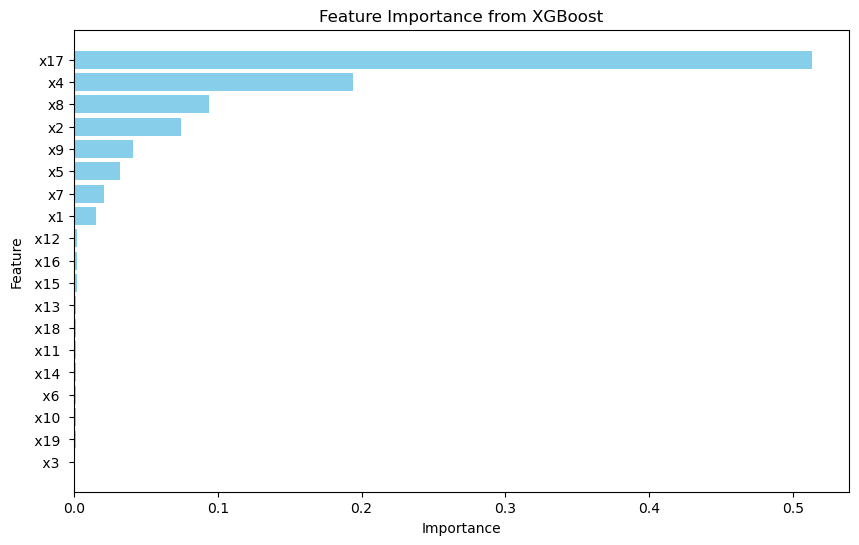

In [17]:
import numpy as np
import pandas as pd
#%pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = drift_data.drop(['outcome'],axis=1)
y = drift_data['outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train an XGBoost model
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display feature importances
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from XGBoost')
plt.gca().invert_yaxis()
plt.show()
